In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import gc
import torch
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from PIL import UnidentifiedImageError
import timm  # Transformer models

In [ ]:
# Avoid CUDA fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Clear memory
gc.collect()
torch.cuda.empty_cache()

In [ ]:
!pip install grad-cam

In [ ]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import matplotlib.pyplot as plt


In [ ]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Dataset class
class ChestXRayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform
        self.label_map = {"normal": 0, "bacterial": 1, "viral": 2}

        for label in self.label_map:
            label_dir = os.path.join(root_dir, label)
            for file in os.listdir(label_dir):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(label_dir, file), self.label_map[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):  # <- This must be inside the class, not outside
        path, label = self.samples[idx]
        try:
            image = Image.open(path).convert("RGB")
        except UnidentifiedImageError:
            print(f"Skipping corrupted file: {path}")
            return self.__getitem__((idx + 1) % len(self.samples))  # Skip corrupted image

        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
# Transforms
img_size = 224
transform_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# Datasets and loaders
train_dataset = ChestXRayDataset("/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/chest_xray_images/train", transform_train)
val_dataset   = ChestXRayDataset("/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/chest_xray_images/val", transform_val_test)
test_dataset  = ChestXRayDataset("/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/chest_xray_images/test", transform_val_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=8, num_workers=2)

In [ ]:
# Modified __getitem__ to Handle Missing Files
def __getitem__(self, idx):
    path, label = self.samples[idx]

    try:
        image = Image.open(path).convert("RGB")
    except (UnidentifiedImageError, FileNotFoundError) as e:
        print(f"Skipping unreadable file: {path}")
        # Safely skip and get another image
        return self.__getitem__((idx + 1) % len(self.samples))

    if self.transform:
        image = self.transform(image)

    return image, label

In [ ]:
# Corrupted or not
def clean_dataset(folder):
    bad_files = []
    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                full_path = os.path.join(root, file)
                try:
                    img = Image.open(full_path)
                    img.verify()
                except Exception as e:
                    print("Corrupted:", full_path)
                    bad_files.append(full_path)
    print(f"\nTotal corrupted: {len(bad_files)}")
    for f in bad_files:
        os.remove(f)

# Run this once
clean_dataset("/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/chest_xray_images")


Total corrupted: 0


In [ ]:
def count_dataset_classes(dataset, dataset_name):
    label_map_inv = {0: 'normal', 1: 'bacterial', 2: 'viral'}
    label_counts = Counter(label for _, label in dataset.samples)

    print(f"\n-->  {dataset_name.upper()} DATASET:")
    for label, count in sorted(label_counts.items()):
        class_name = label_map_inv.get(label, f'class_{label}')
        print(f"  {class_name}: {count} images")

# Count for each dataset
count_dataset_classes(train_dataset, "train")
count_dataset_classes(val_dataset, "val")
count_dataset_classes(test_dataset, "test")


-->  TRAIN DATASET:
  normal: 1808 images
  bacterial: 1945 images
  viral: 1827 images

-->  VAL DATASET:
  normal: 259 images
  bacterial: 278 images
  viral: 261 images

-->  TEST DATASET:
  normal: 517 images
  bacterial: 556 images
  viral: 523 images


In [ ]:
# ResFormer (CNN + ViT Hybrid Model)
class ResFormer(nn.Module):
    def __init__(self, num_classes=3):
        super(ResFormer, self).__init__()

        # ResNet50 backbone
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Transformer backbone (ViT)
        self.transformer = timm.create_model('vit_tiny_patch16_224', pretrained=True)
        self.transformer.head = nn.Identity()

        # Determine feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            cnn_feat = self.avgpool(self.cnn(dummy_input)).view(1, -1)
            vit_feat = self.transformer(dummy_input)
            self.cnn_out_dim = cnn_feat.shape[1]
            self.vit_out_dim = vit_feat.shape[1]

        # Fully connected layer
        self.fc = nn.Linear(self.cnn_out_dim + self.vit_out_dim, num_classes)

    def forward(self, x):
        cnn_feat = self.avgpool(self.cnn(x)).squeeze(-1).squeeze(-1)
        vit_feat = self.transformer(x)
        combined = torch.cat((cnn_feat, vit_feat), dim=1)
        return self.fc(combined)


In [ ]:
save_path = "/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth"

train_acc_list = []
val_acc_list = []
loss_list = []

def train_model(model, train_loader, val_loader, save_path, epochs=10):
    model = model.to(device)
    model.train()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

    best_val_acc = 0.0

    for epoch in range(epochs):
        total_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        val_acc = validate_model(model, val_loader)

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)
        loss_list.append(total_loss / len(train_loader))

        print(f"[Epoch {epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.2f}%, "
              f"Val Acc: {val_acc:.2f}%, "
              f"Loss: {total_loss / len(train_loader):.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f" - Saved new best model at epoch {epoch+1} to: {save_path}")


In [ ]:
#  Validation function
def validate_model(model, val_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    model.train()
    return 100 * correct / total


In [ ]:
#  Evaluation function
def evaluate_model(model):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for idx, (images, labels) in enumerate(test_loader):
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

            if idx % 10 == 0:
                print(f"Processed {idx * len(images)} samples...")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=["normal", "bacterial", "viral"]))

In [ ]:
model = ResFormer()
train_model(model, train_loader, val_loader, save_path, epochs=10)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


[Epoch 1/10] Train Acc: 77.94%, Val Acc: 83.96%, Loss: 0.6653
 - Saved new best model at epoch 1 to: /content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth
[Epoch 2/10] Train Acc: 85.13%, Val Acc: 85.84%, Loss: 0.5603
 - Saved new best model at epoch 2 to: /content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth
[Epoch 3/10] Train Acc: 86.51%, Val Acc: 86.47%, Loss: 0.5306
 - Saved new best model at epoch 3 to: /content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth
[Epoch 4/10] Train Acc: 87.65%, Val Acc: 88.22%, Loss: 0.5093
 - Saved new best model at epoch 4 to: /content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth
[Epoch 5/10] Train Acc: 88.55%, Val Acc: 88.10%, Loss: 0.4938
[Epoch 6/10] Train Acc: 89.52%, Val Acc: 86.47%, Loss: 0.4813


In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/1. All Semester study/1. All about Machine Learning/2. Farhana/Datasets/Models/1.ResFormer.pth"))  # ← This loads the best model
model.to(device)


ResFormer(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64, 25

In [ ]:
print("\nTesting Accuracy:")
model.eval()
evaluate_model(model)


Testing Accuracy:
Processed 0 samples...
Processed 80 samples...
Processed 160 samples...
Processed 240 samples...
Processed 320 samples...
Processed 400 samples...
Processed 480 samples...
Processed 560 samples...
Processed 640 samples...
Processed 720 samples...
Processed 800 samples...
Processed 880 samples...
Processed 960 samples...
Processed 1040 samples...
Processed 1120 samples...
Processed 1200 samples...
Processed 1280 samples...
Processed 1360 samples...
Processed 1440 samples...
Processed 1520 samples...

Confusion Matrix:
[[505   2  10]
 [  3 464  89]
 [ 13  86 424]]

Classification Report:
              precision    recall  f1-score   support

      normal       0.97      0.98      0.97       517
   bacterial       0.84      0.83      0.84       556
       viral       0.81      0.81      0.81       523

    accuracy                           0.87      1596
   macro avg       0.87      0.87      0.87      1596
weighted avg       0.87      0.87      0.87      1596



In [5]:
import matplotlib.pyplot as plt

train_acc_list = []
val_acc_list = []
loss_list = []

def train_model(model, epochs=10):
    ...
    for epoch in range(epochs):
        ...
        epoch_acc = 100 * correct / total
        val_acc = validate_model(model)

        train_acc_list.append(epoch_acc)
        val_acc_list.append(val_acc)
        loss_list.append(total_loss / len(train_loader))

        print(f"Epoch {epoch+1} - Train Acc: {epoch_acc:.2f}%, Val Acc: {val_acc:.2f}%")

print(train_acc_list)
print(val_acc_list)
print(loss_list)

[]
[]
[]


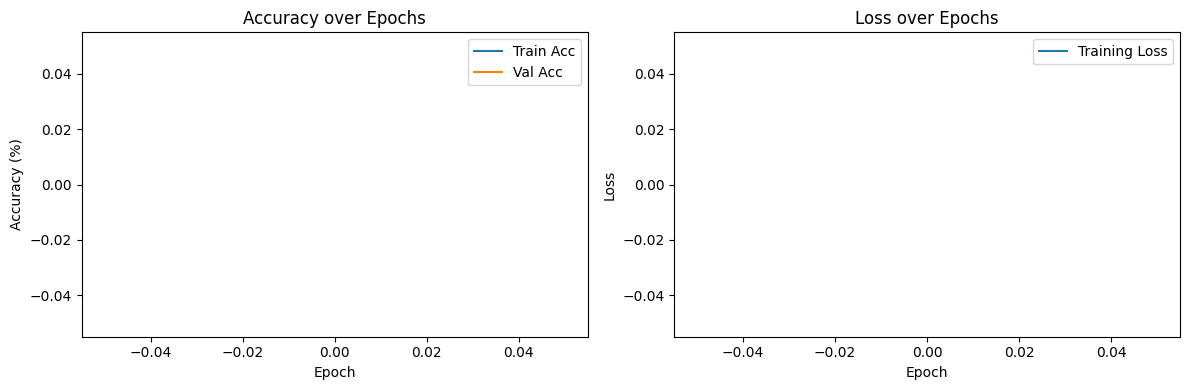

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_list, label='Training Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
target_layer = model.cnn[-1]  # Last CNN layer of ResNet
cam = GradCAMPlusPlus(model=model, target_layers=[target_layer], use_cuda=True)

# Pick a test image
image, label = test_dataset[10]
input_tensor = image.unsqueeze(0).to(device)

# Create CAM
targets = [ClassifierOutputTarget(label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# Convert input to numpy image
image_np = image.permute(1, 2, 0).numpy()
image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
image_np = np.clip(image_np, 0, 1)

# Show overlay
cam_image = show_cam_on_image(image_np, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.title(f"Grad-CAM++ for Class: {label}")
plt.axis('off')
plt.show()

NameError: name 'model' is not defined